# Day 3 Practice: Multi-Agent Systems

**Goal:** Build a complete Multi-Agent system for airline customer service using the τ-bench domain.

**Practice structure:**

| Part | Topic | What we build |
|------|-------|---------------|
| 0 | Environment Setup | Dependencies, model, τ-bench database and tools |
| 1 | Single Agent with TAO Loop | ReAct agent on LangGraph |
| 2 | Multi-Agent Hierarchical System | Coordinator + specialized agents |
| 3 | Critics and Quality Control | CriticAgent + Reflexion pattern |
| 4 | Benchmark and Comparison | Measuring architecture performance |

---
## Part 0: Environment Setup

### 0.1 Dependencies and Imports

In [1]:
# Install dependencies
%pip install -q langchain-openai langchain-core langgraph pydantic typing-extensions

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import time
import copy
from typing import List, Literal
from pydantic import BaseModel, Field
from dataclasses import dataclass
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

MODEL_NAME = 'gpt-4.1-nano'
# os.environ['OPENAI_API_KEY'] = 'api key'

proxyapi_API_KEY = "sk-qcx0VBcsJxDDOi6HF8fv9OT9kypqBnv9"

llm = ChatOpenAI(model=MODEL_NAME, temperature=0, base_url="https://openai.api.proxyapi.ru/v1", api_key=proxyapi_API_KEY)

# Connection check
test_response = llm.invoke([HumanMessage(content='Reply with one word: working?')])
print(f'Model: {MODEL_NAME}')
print(f'Test: {test_response.content}')
print('Setup complete!')

Model: gpt-4.1-nano
Test: Yes
Setup complete!


### 0.2 τ-bench Domain: Database and Tools

**5 tools from τ-bench:**
- `search_flights` — search for flights
- `get_flight_details` — flight details
- `get_booking` — booking information
- `get_policy` — airline policies
- `update_booking` — modify a booking

In [3]:
# === AIRLINE DATABASE ===

FLIGHTS_DB = [
    {
        'flight_number': 'SU2454',
        'departure': 'Moscow (SVO)',
        'arrival': 'Paris (CDG)',
        'departure_time': '08:00',
        'arrival_time': '11:30',
        'date': '2026-04-15',
        'price': 350,
        'available_seats': 15,
        'aircraft': 'Boeing 737',
        'class': 'economy',
    },
    {
        'flight_number': 'SU2456',
        'departure': 'Moscow (SVO)',
        'arrival': 'Paris (CDG)',
        'departure_time': '14:00',
        'arrival_time': '17:30',
        'date': '2026-04-16',
        'price': 370,
        'available_seats': 8,
        'aircraft': 'Airbus A320',
        'class': 'economy',
    },
    {
        'flight_number': 'AF1147',
        'departure': 'Moscow (SVO)',
        'arrival': 'Paris (CDG)',
        'departure_time': '19:20',
        'arrival_time': '22:50',
        'date': '2026-04-16',
        'price': 420,
        'available_seats': 22,
        'aircraft': 'Boeing 777',
        'class': 'business',
    },
    {
        'flight_number': 'SU2460',
        'departure': 'Moscow (SVO)',
        'arrival': 'Paris (CDG)',
        'departure_time': '06:30',
        'arrival_time': '10:00',
        'date': '2026-04-17',
        'price': 330,
        'available_seats': 30,
        'aircraft': 'Airbus A321',
        'class': 'economy',
    },
]

BOOKINGS_DB = {
    'BK-789': {
        'booking_id': 'BK-789',
        'user_id': 'U-1234',
        'flight_number': 'SU2454',
        'passenger_name': 'Ivan Petrov',
        'contact_email': 'ivan@example.com',
        'date': '2026-04-15',
        'class': 'economy',
        'status': 'confirmed',
    },
    'BK-456': {
        'booking_id': 'BK-456',
        'user_id': 'U-5678',
        'flight_number': 'AF1147',
        'passenger_name': 'Anna Smith',
        'contact_email': 'anna@example.com',
        'date': '2026-04-16',
        'class': 'business',
        'status': 'confirmed',
    },
}

POLICIES_DB = {
    'rebooking': {
        'allowed': True,
        'fee': 40,
        'restrictions': 'same class only',
        'deadline_hours': 24,
        'description': 'Rebooking is allowed no later than 24 hours before departure. Only within the same service class. A $40 rebooking fee applies.',
    },
    'cancellation': {
        'allowed': True,
        'fee': 60,
        'refund_percent': 80,
        'deadline_hours': 48,
        'description': 'Cancellation is allowed no later than 48 hours before departure. 80% refund of the ticket price. A $60 cancellation fee applies.',
    },
    'baggage': {
        'economy': {'included_kg': 23, 'extra_per_kg': 5},
        'business': {'included_kg': 32, 'extra_per_kg': 3},
        'oversize': 'Oversized baggage is charged separately, $25.',
        'description': 'Economy: 23 kg included, $5/kg surcharge over the limit. Business: 32 kg included, $3/kg surcharge.',
    },
}


_BOOKINGS_SNAPSHOT = copy.deepcopy(BOOKINGS_DB)


def reset_db():
    """Reset DB to initial state (undo any rebookings from previous tests)."""
    BOOKINGS_DB.clear()
    BOOKINGS_DB.update(copy.deepcopy(_BOOKINGS_SNAPSHOT))


print(f'Flights: {len(FLIGHTS_DB)}')
print(f'Bookings: {len(BOOKINGS_DB)}')
print(f'Policies: {len(POLICIES_DB)}')

Flights: 4
Bookings: 2
Policies: 3


In [4]:
# === TOOLS ===
### TODO: add RETURN to each tool's docstring!!

@tool
def search_flights(origin: str, destination: str, date: str) -> str:
    """Search for flights by route and date.

    Args:
        origin: Departure city or airport code (e.g., 'Moscow', 'SVO')
        destination: Arrival city or airport code (e.g., 'Paris', 'CDG')
        date: Date in YYYY-MM-DD format
    """
    results = [
        flight for flight in FLIGHTS_DB
        if origin.lower().strip() in flight['departure'].lower()
        and destination.lower().strip() in flight['arrival'].lower()
        and flight['date'] == date
    ]

    if not results:
        return json.dumps({
            'status': 'no_results',
            'message': f'No flights found from {origin} to {destination} on {date}',
        })

    return json.dumps({'status': 'success', 'count': len(results), 'flights': results})


@tool
def get_flight_details(flight_number: str) -> str:
    """Get detailed information about a specific flight.

    Args:
        flight_number: Flight number (e.g., 'SU2454')
    """
    for flight in FLIGHTS_DB:
        if flight['flight_number'].upper() == flight_number.upper():
            return json.dumps({'status': 'success', 'flight': flight})

    return json.dumps({'status': 'error', 'message': f'Flight {flight_number} not found'})


@tool
def get_booking(booking_id: str) -> str:
    """Get booking information by ID.

    Args:
        booking_id: Booking identifier (e.g., 'BK-789')
    """
    booking = BOOKINGS_DB.get(booking_id)
    if booking:
        return json.dumps({'status': 'success', 'booking': booking})

    return json.dumps({'status': 'error', 'message': f'Booking {booking_id} not found'})


@tool
def get_policy(policy_type: str) -> str:
    """Get airline policies by type.

    Args:
        policy_type: Policy type ('rebooking', 'cancellation', 'baggage')
    """
    policy = POLICIES_DB.get(policy_type.lower().strip())
    if policy:
        return json.dumps({'status': 'success', 'policy_type': policy_type, 'policy': policy})

    return json.dumps({
        'status': 'error',
        'message': f"Policy '{policy_type}' not found. Available: {list(POLICIES_DB.keys())}",
    })


@tool
def update_booking(booking_id: str, new_flight_number: str, new_date: str) -> str:
    """Update a booking: rebook to a different flight.

    Args:
        booking_id: Booking ID (e.g., 'BK-789')
        new_flight_number: New flight number
        new_date: New date in YYYY-MM-DD format
    """
    booking = BOOKINGS_DB.get(booking_id)
    if not booking:
        return json.dumps({'status': 'error', 'message': f'Booking {booking_id} not found'})

    new_flight = None
    for f in FLIGHTS_DB:
        if f['flight_number'].upper() == new_flight_number.upper() and f['date'] == new_date:
            new_flight = f
            break

    if not new_flight:
        return json.dumps({
            'status': 'error',
            'message': f'Flight {new_flight_number} on {new_date} not found',
        })

    if booking['class'] != new_flight['class']:
        return json.dumps({
            'status': 'error',
            'message': (
                f'Class mismatch: booking is {booking["class"]}, '
                f'flight is {new_flight["class"]}. Policy: same class only.'
            ),
        })

    updated = dict(booking)
    updated['flight_number'] = new_flight_number
    updated['date'] = new_date
    updated['status'] = 'rebooked'
    BOOKINGS_DB[booking_id] = updated

    rebooking_fee = POLICIES_DB['rebooking']['fee']

    return json.dumps({
        'status': 'success',
        'message': f'Booking {booking_id} rebooked to {new_flight_number} on {new_date}',
        'fee_applied': rebooking_fee,
        'updated_booking': updated,
    })


ALL_TOOLS = [search_flights, get_flight_details, get_booking, get_policy, update_booking]

print('Tools:', [t.name for t in ALL_TOOLS])

Tools: ['search_flights', 'get_flight_details', 'get_booking', 'get_policy', 'update_booking']


---
## Part 1: Single Agent with TAO Loop (ReAct)

The simplest agent architecture: one LLM + tools, operating in a loop:

```
Thought → Action → Observation → Thought → ... → Final Answer
```

**What we build:** a ReAct agent on LangGraph with explicit THOUGHT step visualization.

### 1.1 Preparation: System Prompt

In [6]:
# === System prompt for ReAct agent ===

REACT_SYSTEM_PROMPT = """You are an airline customer support agent. Follow the TAO loop:

THOUGHT: Analyze the request, plan the steps
ACTION: Call the appropriate tool to get information
OBSERVATION: Analyze the result, determine if further actions are needed

Available tools:
- search_flights: search flights by route and date
- get_flight_details: detailed flight information
- get_booking: booking information
- get_policy: airline policies (rebooking, cancellation, baggage)
- update_booking: rebook to a different flight

IMPORTANT:
- Call only ONE tool per step. Get the result, analyze it, then decide what to do next
- Always check policies (get_policy) before modifying a booking
- Do not fabricate information — only use data from tools
- Ask for user confirmation before rebooking/cancellation
- Be polite and helpful to the customer
"""

print('System prompt ready (ReAct)')

System prompt ready (ReAct)


### 1.2 Implementation: ReAct Agent (LangGraph)

ReAct agent created


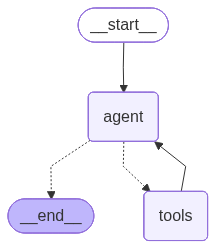

In [7]:
# === ReAct Agent on LangGraph ===

### TODO: below is UNUSED THOUGHT!!!

def create_react_agent(tools_list=None, system_prompt=None):
    """Creates a ReAct agent with the given tools.

    Includes an explicit THOUGHT step: if the model calls a tool
    without writing reasoning text (common with function-calling),
    we make an extra LLM call to extract the reasoning.
    """
    if tools_list is None:
        tools_list = ALL_TOOLS
    if system_prompt is None:
        system_prompt = REACT_SYSTEM_PROMPT

    # parallel_tool_calls=False — forces the model to call one tool per step,
    # making the TAO loop explicit: Thought → Action → Observation → Thought → ...
    llm_with_tools = llm.bind_tools(tools_list, parallel_tool_calls=False)

    def agent_node(state: MessagesState):
        messages = state['messages']
        # Add system prompt if not present yet
        if not any(isinstance(msg, SystemMessage) for msg in messages):
            messages = [SystemMessage(content=system_prompt)] + messages
        response = llm_with_tools.invoke(messages)

        if response.tool_calls and not response.content:
            tool_info = ', '.join(tc['name'] for tc in response.tool_calls)
            thought = llm.invoke(
                messages
                + [
                    HumanMessage(
                        content=f'You chose to call: {tool_info}. '
                        'In 1 sentence, explain why this is the right next step. '
                        'Reply with ONLY your reasoning, no tool calls.'
                    )
                ]
            )
            response.content = thought.content

        return {'messages': [response]}

    def should_continue(state: MessagesState):
        last_message = state['messages'][-1]
        if last_message.tool_calls:
            return 'tools'
        return END

    # Build the graph
    workflow = StateGraph(MessagesState)
    workflow.add_node('agent', agent_node)
    workflow.add_node('tools', ToolNode(tools_list))

    workflow.add_edge(START, 'agent')
    workflow.add_conditional_edges('agent', should_continue, {'tools': 'tools', END: END})
    workflow.add_edge('tools', 'agent')

    return workflow.compile()


react_agent = create_react_agent()
print('ReAct agent created')
react_agent

In [28]:
# === Visualization: Pretty-print for ReAct + MAS + Critic ===

from IPython.display import display, HTML
import html as html_module
import json as json_module


def _compact_args(args):
    if not args:
        return ""
    if isinstance(args, dict):
        return ", ".join(f"{k}={json_module.dumps(v, ensure_ascii=False)}" for k, v in args.items())
    return str(args)


def _css():
    return """<style>
      .trace{font-family:Arial,sans-serif;line-height:1.4;margin:12px 0}
      .trace-title{font-size:16px;font-weight:700;margin:0 0 10px;color:#111827}
      .trace-stats{font-size:12px;color:#6b7280;margin:6px 0 8px;padding:4px 0;
                   border-top:1px solid #e5e7eb}

      /* TAO cycle group */
      .tao-group{border-left:3px solid #e5e7eb;margin:8px 0 8px 4px;padding-left:12px}
      .tao-header{font-size:12px;font-weight:700;color:#374151;margin:0 0 4px;
                  letter-spacing:0.5px}

      /* rows */
      .row{display:flex;gap:8px;align-items:flex-start;padding:5px 10px;margin:2px 0;
           border-radius:6px;border:1px solid #e5e7eb;background:#fff}
      .badge{min-width:70px;text-align:center;font-size:10px;font-weight:700;
             border-radius:4px;padding:3px 6px;color:#fff;flex-shrink:0;
             text-transform:uppercase;letter-spacing:0.5px}
      .msg{white-space:pre-wrap;flex:1;font-size:13px}

      /* badge colors */
      .user-row .badge{background:#2563eb}
      .t-row .badge{background:#0891b2}
      .a-row .badge{background:#d97706}
      .o-row .badge{background:#7c3aed}
      .answer-row .badge{background:#16a34a}
      .answer-row{border:1px solid #16a34a;background:#f0fdf4}

      /* tool call styling */
      .tool-call{font-family:Consolas,monospace;font-size:12px}
      .tool-call b{color:#92400e}

      /* MAS specific */
      .plan-box{border:1px solid #d97706;border-radius:8px;padding:8px 12px;margin:6px 0;
                background:#fffbeb;font-size:12px;line-height:1.5}
      .plan-box b{color:#92400e}
      .agent-row .badge{background:#7c3aed}
      .agent-row{border-left:3px solid #7c3aed}
      .synth-row .badge{background:#059669}
      .synth-row{border:1px solid #059669;background:#f0fdf4}
      .sub{margin-top:3px;font-size:11px;color:#6b7280}

      /* Critic */
      .critic-box{border:2px solid #dc2626;border-radius:8px;padding:8px 12px;margin:6px 0;
                  background:#fef2f2;font-size:13px;line-height:1.5}
      .critic-box.approved{border-color:#16a34a;background:#f0fdf4}
      .critic-box b{color:#374151}
    </style>"""


def pretty_print_react(result_dict, title="ReAct Agent", elapsed=None, max_chars=12000):
    """Render a ReAct agent trace as styled HTML with numbered TAO cycles."""
    messages = result_dict.get("messages", [])
    parts = [_css(), '<div class="trace">',
             f'<div class="trace-title">{html_module.escape(title)}</div>']

    # Group messages into TAO cycles
    # Pattern: AIMessage(with tool_calls) -> ToolMessage(s) -> repeat... -> AIMessage(final)
    cycle = 0
    total_tools = 0
    i = 0
    while i < len(messages):
        msg = messages[i]
        kind = type(msg).__name__
        content = (getattr(msg, "content", "") or "")

        # User message
        if kind == "HumanMessage":
            parts.append(f'<div class="row user-row"><span class="badge">User</span>'
                         f'<span class="msg">{html_module.escape(content[:max_chars])}</span></div>')
            i += 1
            continue

        # AI with tool calls -> start of a TAO cycle
        if kind == "AIMessage" and hasattr(msg, "tool_calls") and msg.tool_calls:
            cycle += 1
            parts.append(f'<div class="tao-group">')
            parts.append(f'<div class="tao-header">TAO Cycle {cycle}</div>')

            # T: Thought
            thought = content[:max_chars].strip()
            if thought:
                parts.append(
                    f'<div class="row t-row"><span class="badge">T {cycle}</span>'
                    f'<span class="msg">{html_module.escape(thought)}</span></div>')
            else:
                parts.append(
                    f'<div class="row t-row"><span class="badge">T {cycle}</span>'
                    f'<span class="msg" style="color:#9ca3af"><i>(implicit)</i></span></div>')

            # A: Action(s)
            for tc in msg.tool_calls:
                total_tools += 1
                call_str = (f"<b>{html_module.escape(tc['name'])}</b>"
                            f"({html_module.escape(_compact_args(tc['args']))})")
                parts.append(
                    f'<div class="row a-row"><span class="badge">A {cycle}</span>'
                    f'<span class="msg tool-call">{call_str}</span></div>')

            i += 1

            # O: Observation(s) -- collect subsequent ToolMessages
            while i < len(messages) and type(messages[i]).__name__ == "ToolMessage":
                obs = (getattr(messages[i], "content", "") or "")[:max_chars]
                parts.append(
                    f'<div class="row o-row"><span class="badge">O {cycle}</span>'
                    f'<span class="msg">{html_module.escape(obs)}</span></div>')
                i += 1

            parts.append('</div>')  # close tao-group
            continue

        # Final AI answer (no tool calls)
        if kind == "AIMessage" and content.strip():
            parts.append(
                f'<div class="row answer-row"><span class="badge">Answer</span>'
                f'<span class="msg">{html_module.escape(content[:12000])}</span></div>')
            i += 1
            continue

        i += 1  # skip system or empty messages

    # Stats
    stats = f"TAO cycles: {cycle} | Tool calls: {total_tools}"
    if elapsed is not None:
        stats += f" | Time: {elapsed:.2f}s"
    parts.append(f'<div class="trace-stats">{stats}</div>')
    parts.append("</div>")
    display(HTML("".join(parts)))


def pretty_print_mas(user_query, plan, agent_results, final_answer,
                     title="Multi-Agent System", elapsed=None, max_chars=500):
    """Render MAS execution: plan -> agent results -> synthesis."""
    parts = [_css(), '<div class="trace">',
             f'<div class="trace-title">{html_module.escape(title)}</div>']

    # User query
    parts.append(f'<div class="row user-row"><span class="badge">User</span>'
                 f'<span class="msg">{html_module.escape(user_query[:max_chars])}</span></div>')

    # Plan
    if plan:
        plan_lines = [f"<b>Plan:</b> {html_module.escape(plan.reasoning)}"]
        for idx, st in enumerate(plan.subtasks, 1):
            prio = "!" * st.priority
            plan_lines.append(
                f'{idx}. <b>{html_module.escape(st.agent_name)}</b> '
                f'[P{st.priority}]: {html_module.escape(st.description[:200])}')
        parts.append(f'<div class="plan-box">{"<br>".join(plan_lines)}</div>')

    # Agent results
    for r in (agent_results or []):
        status_icon = {"success": "ok", "error": "ERR", "partial": "..."}
        icon = status_icon.get(r.status, "?")
        tools_str = ""
        if r.tools_used:
            tools_str = f' | tools: {", ".join(r.tools_used)}'
        result_preview = html_module.escape((r.result or "")[:max_chars])
        parts.append(
            f'<div class="row agent-row"><span class="badge">{html_module.escape(r.agent_name)}</span>'
            f'<span class="msg">{result_preview}'
            f'<div class="sub">[{icon}]{tools_str}</div></span></div>')

    # Final answer
    if final_answer:
        parts.append(
            f'<div class="row synth-row"><span class="badge">Answer</span>'
            f'<span class="msg">{html_module.escape(final_answer[:800])}</span></div>')

    if elapsed is not None:
        agents_count = len(agent_results or [])
        total_tools = sum(len(r.tools_used) for r in (agent_results or []))
        parts.append(
            f'<div class="trace-stats">Agents: {agents_count} | '
            f'Total tool calls: {total_tools} | Time: {elapsed:.2f}s</div>')
    parts.append("</div>")
    display(HTML("".join(parts)))


def pretty_print_critic(feedback, title="Critic Review"):
    """Render critic feedback as a styled box."""
    cls = "approved" if feedback.approved else ""
    status = "APPROVED" if feedback.approved else "NEEDS REVISION"
    parts = [_css(), f'<div class="critic-box {cls}">']
    parts.append(f'<b>Critic:</b> {status} | Score: {feedback.score}/10<br>')
    if feedback.issues:
        parts.append(f'<b>Issues:</b> {html_module.escape(", ".join(feedback.issues))}<br>')
    if feedback.suggestions:
        parts.append(f'<b>Suggestions:</b> {html_module.escape(", ".join(feedback.suggestions))}<br>')
    parts.append(f'<i>{html_module.escape(feedback.reasoning[:400])}</i>')
    parts.append('</div>')
    display(HTML("".join(parts)))


# === Updated run_and_trace with HTML output ===

def run_and_trace(agent, query: str, title=None):
    """Runs the agent and displays the TAO loop as styled HTML."""
    start_time = time.time()
    result = agent.invoke({"messages": [HumanMessage(content=query)]})
    elapsed = time.time() - start_time
    pretty_print_react(result, title=title or f"ReAct: {query[:60]}", elapsed=elapsed)

    steps = sum(1 for m in result["messages"]
                if type(m).__name__ == "AIMessage" and hasattr(m, "tool_calls") and m.tool_calls)
    return result, list(range(1, steps + 1))


print("Visualization ready: pretty_print_react, pretty_print_mas, pretty_print_critic, run_and_trace")


Visualization ready: pretty_print_react, pretty_print_mas, pretty_print_critic, run_and_trace


### 1.3 Testing

Three tests with increasing complexity:
1. **Simple query** — single tool call
2. **Multi-step with explicit instructions** — agent is told exactly what to do
3. **Natural multi-domain query** — same information needed, but phrased naturally without instructions (motivation for MAS)

In [12]:
# === Test 1: Flight Search ===
# Simple query — the agent should call search_flights

result1, steps1 = run_and_trace(
    react_agent,
    'Find flights from Moscow to Paris on April 16, 2026',
)

In [13]:
# === Test 2: Rebooking (multi-step TAO) ===
# The query is designed so the agent MUST first look up the route from the booking,
# then search for flights — this forces sequential steps

result2, steps2 = run_and_trace(
    react_agent,
    'I have booking BK-789. Look up my booking details, find flights on the same route for April 16, 2026, and check the rebooking policy.',
)

In [14]:
# === Test 3: Natural Multi-Domain Query (motivation for MAS) ===
# The user asks a question spanning 3 domains: booking, policies, flights.
# Requires 4 tool calls: get_booking, get_policy(rebooking), get_policy(cancellation), search_flights.
# A single ReAct agent must figure out ALL of them on its own.

reset_db()

result3, steps3 = run_and_trace(
    react_agent,
    'I have booking BK-789 (Moscow-Paris, April 15, 2026). Should I cancel or rebook '
    'to April 16, 2026? Compare the costs and show me available flights.',
)

# Compare with Test 2: there the agent was told exactly what to do (3 tools, 3 steps).
# Here the query is natural and multi-domain — does the agent cover all 4 tools?

**Result** agent did not answer about `should I rebook or cancel?`

### 1.4 Takeaways

**What we saw:**
- Single Agent handles simple and explicit multi-step queries well (Tests 1, 2)
- On **natural multi-domain queries** (Test 3) the agent partially fails: it may skip some domains (e.g., not comparing cancellation vs rebooking), producing an incomplete answer
- A single agent must figure out ALL subtasks on its own — with no decomposition guarantee

**Key problem:** one agent with many responsibilities = incomplete coverage on complex queries.

**This motivates Part 2** — a multi-agent system where a coordinator decomposes the task and specialized agents handle each domain.

---
## Part 2: Multi-Agent Hierarchical System

A single agent cannot be an expert at everything. MAS principles:

1. **Decomposition** — break the task into subtasks
2. **Specialization** — each agent is an expert in their domain
3. **Communication** — exchange structured data
4. **Coordination** — a coordinator manages the process

**What we build:** Coordinator (orchestrator) + 3 specialized agents (flight, booking, policy).

### 2.1 Preparation: Structured Communication (Pydantic Schemas)

In [15]:
# === Structured Output for MAS (as in the lecture) ===


class SubTask(BaseModel):
    """Subtask for a specialized agent."""

    agent_name: Literal['flight_agent', 'policy_agent', 'booking_agent']
    description: str = Field(description='What needs to be done')
    priority: int = Field(ge=1, le=3, description='1=highest, 3=lowest')


class CoordinatorPlan(BaseModel):
    """Coordinator plan: decomposition into subtasks."""

    reasoning: str = Field(description='Why this decomposition was chosen')
    subtasks: List[SubTask] = Field(description='List of subtasks in execution order')


class AgentResult(BaseModel):
    """Result from a specialized agent."""

    agent_name: str
    status: Literal['success', 'error', 'partial']
    result: str
    tools_used: List[str] = Field(default_factory=list)


print('Structured schemas defined')

example_plan = CoordinatorPlan(
    reasoning='The rebooking request requires: 1) check current booking, 2) look up policies, 3) find new flights',
    subtasks=[
        SubTask(agent_name='booking_agent', description='Get booking data for BK-789', priority=1),
        SubTask(agent_name='policy_agent', description='Get rebooking policy', priority=1),
        SubTask(agent_name='flight_agent', description='Find Moscow-Paris flights for April 16', priority=2),
    ],
)
print(f'\nExample plan: {len(example_plan.subtasks)} subtasks')
for st in example_plan.subtasks:
    print(f'  [{st.priority}] {st.agent_name}: {st.description}')

Structured schemas defined

Example plan: 3 subtasks
  [1] booking_agent: Get booking data for BK-789
  [1] policy_agent: Get rebooking policy
  [2] flight_agent: Find Moscow-Paris flights for April 16


### 2.2 Implementation: Specialized Agents and Coordinator

In [ ]:
# === Specialized Agents ===
# They are NOT ReAct (from their prompt). But in function they demand the thinking step!!!

class SpecializedAgent:
    """Base class for a specialized agent in MAS."""

    def __init__(self, name: str, tools_list: list, system_prompt: str):
        self.name = name
        self.tools = tools_list
        self.graph = create_react_agent(tools_list, system_prompt)

    def process(self, task_description: str) -> AgentResult:
        """Processes a task and returns a structured result."""
        try:
            result = self.graph.invoke({
                'messages': [HumanMessage(content=task_description)]
            })

            tools_used = []
            for msg in result['messages']:
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    tools_used.extend([tc['name'] for tc in msg.tool_calls])

            final_content = result['messages'][-1].content

            return AgentResult(
                agent_name=self.name,
                status='success',
                result=final_content,
                tools_used=tools_used,
            )
        except Exception as e:
            return AgentResult(
                agent_name=self.name,
                status='error',
                result=f'Error: {e}',
                tools_used=[],
            )


flight_agent = SpecializedAgent(
    name='FlightAgent',
    tools_list=[search_flights, get_flight_details],
    system_prompt="""You are a flight search expert. Your tasks:
- Find flights matching the user's criteria
- Compare options by price, time, and convenience
- Provide a brief recommendation
Use only the available tools. Do not fabricate data.""",
)

policy_agent = SpecializedAgent(
    name='PolicyAgent',
    tools_list=[get_policy],
    system_prompt="""You are an airline policy expert. Your tasks:
- Provide accurate policy information
- Explain fees and restrictions
- Highlight important conditions (deadlines, class restrictions)
Use get_policy to retrieve current data.""",
)

booking_agent = SpecializedAgent(
    name='BookingAgent',
    tools_list=[get_booking, update_booking],
    system_prompt="""You are a booking management expert. Your tasks:
- Retrieve current booking data
- Execute rebooking when instructed
- Check booking status and details
IMPORTANT: before updating a booking, ensure a specific flight and date are provided.""",
)

SPECIALIST_AGENTS = {
    'flight_agent': flight_agent,
    'policy_agent': policy_agent,
    'booking_agent': booking_agent,
}

print('Specialized agents:')
for name, agent in SPECIALIST_AGENTS.items():
    print(f'  {name}: tools={[t.name for t in agent.tools]}')

Specialized agents:
  flight_agent: tools=['search_flights', 'get_flight_details']
  policy_agent: tools=['get_policy']
  booking_agent: tools=['get_booking', 'update_booking']


In [17]:
# === Coordinator (Orchestrator) ===


class CoordinatorAgent:
    """Multi-Agent system coordinator (Hierarchical Architecture)."""

    def __init__(self, specialist_agents: dict):
        self.agents = specialist_agents
        self.planning_llm = llm.with_structured_output(CoordinatorPlan)
        self.synthesis_llm = llm

    def create_plan(self, user_query: str) -> CoordinatorPlan:
        """Step 1: Decompose the request into subtasks."""
        return self.planning_llm.invoke([
            SystemMessage(content="""You are the coordinator of an airline agent team.
You have 3 specialists:
- flight_agent: flight search (search_flights, get_flight_details)
- policy_agent: company policies (get_policy). Available types: rebooking, cancellation, baggage
- booking_agent: bookings (get_booking, update_booking)

Break the user's request into subtasks for the specialists.
Specify priority (1=highest) and execution order.

CRITICAL RULES for subtask descriptions:
- Each subtask description MUST be self-contained — the specialist has NO context beyond its description.
- ALWAYS include explicit city names (e.g. "Moscow to Paris"), dates with year (e.g. "April 16, 2026"), booking IDs, and class.
- NEVER write vague descriptions like "search for flights on the route of the booking" — write "search for flights from Moscow to Paris on April 16, 2026".
- Current year: 2026."""),
            HumanMessage(content=user_query),
        ])

    def execute_plan(self, plan: CoordinatorPlan) -> List[AgentResult]:
        """Step 2: Delegate tasks to specialists."""
        results = []
        sorted_tasks = sorted(plan.subtasks, key=lambda t: t.priority)

        for task in sorted_tasks:
            agent = self.agents.get(task.agent_name)
            if not agent:
                results.append(AgentResult(
                    agent_name=task.agent_name, status='error',
                    result=f"Agent '{task.agent_name}' not found",
                ))
                continue

            print(f'  [{task.agent_name}] {task.description}')
            result = agent.process(task.description)
            results.append(result)
            print(f'  -> {result.status} (tools: {result.tools_used})')

        return results

    def synthesize(self, user_query: str, results: List[AgentResult]) -> str:
        """Step 3: Synthesize responses into a single answer."""
        results_text = '\n\n'.join([
            f'[{r.agent_name}] ({r.status}):\n{r.result}' for r in results
        ])

        response = self.synthesis_llm.invoke([
            SystemMessage(content="""You are the coordinator. Combine the specialists' results
into a single coherent response for the customer. Be polite and informative.
Do not repeat internal details, only include information useful to the customer.
Use ONLY facts from the specialist results below. Do NOT invent or assume any data."""),
            HumanMessage(content=f'Customer request: {user_query}\n\nSpecialist results:\n{results_text}'),
        ])
        return response.content

    def process_query(self, user_query: str) -> tuple:
        """Full query processing cycle. Returns (answer, results, plan, elapsed)."""
        start_time = time.time()

        plan = self.create_plan(user_query)
        results = self.execute_plan(plan)
        final_answer = self.synthesize(user_query, results)

        elapsed = time.time() - start_time
        return final_answer, results, plan, elapsed


coordinator = CoordinatorAgent(SPECIALIST_AGENTS)
print('Coordinator created')


Coordinator created


### 2.3 Testing: Same Query, Different Architecture

We test the MAS on the **same query** that the Single Agent failed on in Test 3. This is a direct comparison.

In [22]:
# === MAS Test: Same Query as Test 3 ===
reset_db()

query_mas = (
    'I have booking BK-789 (Moscow-Paris, April 15, 2026). Should I cancel or rebook '
    'to April 16, 2026? Compare the costs and show me available flights.'
)
answer_mas, results_mas, plan_mas, elapsed_mas = coordinator.process_query(query_mas)
pretty_print_mas(query_mas, plan_mas, results_mas, answer_mas,
    title="MAS: Multi-domain query", elapsed=elapsed_mas)


  [booking_agent] Retrieve details of booking BK-789 to Moscow-Paris on April 15, 2026.
  -> success (tools: ['get_booking'])
  [flight_agent] Search for available flights from Moscow to Paris on April 16, 2026.
  -> success (tools: ['search_flights'])
  [policy_agent] Get company policies related to rebooking and cancellation costs.
  -> success (tools: ['get_policy', 'get_policy'])


In [23]:
# === MAS Test: Complex Query ===

query_mas2 = 'Tell me about the baggage rules for economy class and find the cheapest Moscow-Paris flight on April 17, 2026'
answer_mas2, results_mas2, plan_mas2, elapsed_mas2 = coordinator.process_query(query_mas2)
pretty_print_mas(query_mas2, plan_mas2, results_mas2, answer_mas2,
    title="MAS: Baggage + flight search", elapsed=elapsed_mas2)


  [policy_agent] Get baggage rules for economy class.
  -> success (tools: ['get_policy'])
  [flight_agent] Search for the cheapest flight from Moscow to Paris on April 17, 2026.
  -> success (tools: ['search_flights'])


### 2.4 Takeaways

**What we saw:**
- MAS handles the same natural multi-domain query that Single Agent struggled with
- The coordinator correctly decomposes the request into subtasks across all relevant domains
- Structured communication (Pydantic schemas) ensures reliable data exchange

**Trade-off:** MAS uses more LLM calls and is slower, but produces more complete answers on complex queries.

**This motivates Part 3** — adding a Critic to verify quality before sending the answer.

---
## Part 3: Critics and Quality Control

One of the 6 MAS principles is **Verification**. The Critic Agent:
- Analyzes other agents' results
- Identifies errors, missing data, policy violations
- Does not act — only evaluates

**Reflexion** pattern (Shinn et al., 2023):

```
Agent → Result → Critic → Approved?  ── Yes ──> User
                              │
                             No → Agent (retry with feedback)
```

**What we build:** CriticAgent with structured feedback + EnhancedCoordinator with revision loop.

### 3.1 Preparation: Feedback Schema and Critic Agent

In [25]:
# === Critic Agent ===


class CriticFeedback(BaseModel):
    """Structured critic feedback"""

    reasoning: str = Field(description='Reasoning behind the score')
    issues: List[str] = Field(default_factory=list, description='Issues found')
    suggestions: List[str] = Field(default_factory=list, description='Suggestions')
    score: float = Field(ge=0.0, le=10.0, description='Score 0-10')
    approved: bool = Field(description='Whether the answer is approved')

class CriticAgent:
    """Critic agent: checks answer quality before sending to the customer."""

    def __init__(self):
        self.critic_llm = llm.with_structured_output(CriticFeedback)

    def review(
        self,
        user_query: str,
        proposed_answer: str,
        agent_results: List[AgentResult] = None,
    ) -> CriticFeedback:
        """Reviews the answer for quality, completeness, and correctness"""

        context = ''
        if agent_results:
            context = '\n\nData from specialists:\n' + '\n'.join([
                f'[{r.agent_name}]: {r.result[:500]}' for r in agent_results
            ])

        feedback = self.critic_llm.invoke([
            SystemMessage(
                content="""You are a quality assurance critic for an airline's customer responses.

Evaluate the proposed answer using ONLY the specialist data provided below. Check:

1. COMPLETENESS: Does the answer address all parts of the customer's question?
2. CORRECTNESS: Does the answer accurately reflect the specialist data? Do NOT flag missing info that was never requested.
3. SAFETY: Are there risky or misleading recommendations?
4. POLITENESS: Is the tone customer-friendly?
5. SPECIFICITY: Are concrete numbers (prices, fees, flight times) included when available in the data?

IMPORTANT:
- Only flag issues that are DIRECTLY supported by the specialist data or the customer's question.
- Do NOT invent problems or request information the customer did not ask for.
- If the specialist data contains facts and the answer reflects them correctly, that is sufficient.

Score from 0 to 10. Set approved=true only when score >= 7."""
            ),
            HumanMessage(content=f'Customer request: {user_query}\n\nProposed answer:\n{proposed_answer}{context}'),
        ])

        return feedback


critic = CriticAgent()
print('Critic agent created')

Critic agent created


### 3.2 Implementation: Enhanced Coordinator with Critic

In [26]:
# === Enhanced Coordinator with Critic ===
# Limitation: no loop after critic: just 1 llm call for fixing based on feedback and then once more evaluation

class EnhancedCoordinator(CoordinatorAgent):
    """Coordinator with integrated quality control."""

    def __init__(self, specialist_agents: dict, max_revisions: int = 1):
        super().__init__(specialist_agents)
        self.critic = CriticAgent()
        self.max_revisions = max_revisions

    def process_query_with_qc(self, user_query: str) -> tuple:
        """Process a query with quality control. Returns (answer, results, feedback, plan, elapsed)."""
        start_time = time.time()

        plan = self.create_plan(user_query)
        results = self.execute_plan(plan)
        answer = self.synthesize(user_query, results)

        feedback = self.critic.review(user_query, answer, results)

        if not feedback.approved and self.max_revisions > 0:

            # Pass specialist data to revision so it doesn't hallucinate
            results_text = '\n'.join([
                f'[{r.agent_name}]: {r.result[:500]}' for r in results
            ])
            revision_prompt = (
                f'Improve the answer based on the critic\'s feedback.\n'
                f'Issues: {feedback.issues}\n'
                f'Suggestions: {feedback.suggestions}\n\n'
                f'Original answer:\n{answer}\n\n'
                f'Specialist data (use ONLY this data, do NOT invent facts):\n{results_text}'
            )
            revised = self.synthesis_llm.invoke([
                SystemMessage(
                    content='You are the coordinator. Improve the answer based on critic feedback. '
                    'Use ONLY the specialist data provided. Do NOT invent or assume any facts.'
                ),
                HumanMessage(content=revision_prompt),
            ])
            answer = revised.content

            feedback = self.critic.review(user_query, answer, results)
            print(f'  Revised score: {feedback.score}/10 | Approved: {feedback.approved}')

        elapsed = time.time() - start_time
        return answer, results, feedback, plan, elapsed


enhanced_coordinator = EnhancedCoordinator(SPECIALIST_AGENTS)
print('Enhanced coordinator with critic created')


Enhanced coordinator with critic created


### 3.3 Testing

In [29]:
# === Test MAS + Critic: Rebooking with Class Restriction ===
reset_db()

query_qc = (
    'I have booking BK-789 (Moscow-Paris, economy class). I want to rebook to '
    'the latest available flight on April 16, 2026. How much will it cost me in total?'
)
answer_qc, results_qc, feedback_qc, plan_qc, elapsed_qc = enhanced_coordinator.process_query_with_qc(query_qc)
pretty_print_mas(query_qc, plan_qc, results_qc, answer_qc,
    title="MAS + Critic: Class restriction test", elapsed=elapsed_qc)
pretty_print_critic(feedback_qc)


  [booking_agent] Get details of booking BK-789 (Moscow to Paris, economy class) to understand current reservation.
  -> success (tools: ['get_booking'])
  [policy_agent] Retrieve the company's rebooking policy to identify applicable fees and rules.
  -> success (tools: ['get_policy'])
  [flight_agent] Search for available flights from Moscow to Paris on April 16, 2026, in economy class.
  -> success (tools: ['search_flights'])


### 3.4 Takeaways

Critic Agent adds:
- **Verification** — the answer is checked before being sent to the customer
- **Feedback loop** — if score < 7, the answer is revised (Step 5: Revision)
- **Measurability** — numerical quality score (score 0-10)

Trade-off: +1-2 LLM calls (extra latency), but higher reliability on tricky queries.

Important: a nano-model **is not calibrated for evaluation tasks** — it may find non-existent issues and underscore good answers. The critic should be more powerful than the evaluated agent: if agents run on nano, the critic should run on mini or higher. Otherwise, the critic understands the answer worse than the one who wrote it.

**Rule:** in critical domains (finance, healthcare, aviation) — **always** add a Critic.

---
## Part 4: Benchmark and Architecture Comparison

Comparing three approaches on the same scenarios using **fact-based objective scoring** — we check whether the response contains specific expected facts (prices, fees, flight numbers, policy details).

| Architecture | Description |
|---|---|
| Single Agent (ReAct) | One agent with all tools |
| Hierarchical MAS | Coordinator + 3 specialists |
| MAS + Critic | MAS with quality control |

### 4.1 Preparation: Benchmark Infrastructure

In [31]:
# === Benchmarking System ===

import re


@dataclass
class BenchmarkResult:
    architecture: str
    query: str
    response: str
    execution_time: float
    llm_calls: int
    tool_calls: int
    success: bool
    fact_score: float = 0.0
    facts_found: list = None
    facts_missed: list = None


# Three queries of increasing complexity — each highlights a different architecture gap.
TEST_QUERIES = [
    {
        'query': 'What are the baggage rules for economy class?',
        'complexity': 'simple',
        'expected_tools': ['get_policy'],
    },
    {
        'query': (
            'I have booking BK-789 (Moscow-Paris, April 15, 2026). Should I cancel or rebook '
            'to April 16, 2026? Compare the costs and show me available flights.'
        ),
        'complexity': 'multi-domain',
        'expected_tools': ['get_booking', 'get_policy', 'get_policy', 'search_flights'],
    },
    {
        'query': (
            'I have booking BK-789 (Moscow-Paris, economy class). I want to rebook to '
            'the latest available flight on April 16, 2026. How much will it cost me in total?'
        ),
        'complexity': 'tricky',
        'expected_tools': ['get_booking', 'get_policy', 'search_flights'],
    },
]


# === Fact-Based Objective Scoring ===
# Instead of using an LLM as judge (unreliable with nano models),
# we check for presence of specific facts that a correct answer MUST contain.

EXPECTED_FACTS = {
    'simple': [
        (r'23', '23 kg included'),
        (r'\$5|5.{0,5}kg|5.{0,5}per', '$5/kg extra fee'),
        (r'oversize|over.size|\$25|25.{0,10}(bag|lug|charg)', 'Oversize baggage ($25)'),
    ],
    'multi-domain': [
        (r'\$60|60.{0,10}(fee|cancel|charg)|cancellation.{0,15}(fee|\$|60)', 'Cancellation fee ($60)'),
        (r'80\s*%|80\s*percent|eighty.{0,5}percent', '80% refund'),
        (r'\$40|40.{0,10}(fee|rebook|charg)|rebooking.{0,15}(fee|\$|40)', 'Rebooking fee ($40)'),
        (r'SU\s*2456|14:00|14.00|\$?370', 'Flight SU2456 info ($370, 14:00)'),
        (r'(cancel|rebook).{0,80}(rebook|cancel)|compar|both.{0,20}option|option', 'Both options discussed'),
    ],
    'tricky': [
        (r'SU\s*2456|14:00|\$?370', 'Economy option SU2456'),
        (r'AF\s*1147|19:20|business', 'Latest flight AF1147 (business)'),
        (r'(class|econom|business).{0,40}(restrict|mismatch|not.{0,5}allow|same.class|cannot|only)', 'Class restriction flagged'),
        (r'\$?40|rebooking.{0,10}fee', 'Rebooking fee ($40)'),
        (r'\$?410|370.{0,20}40|40.{0,20}370|total.{0,20}(cost|\$)', 'Total cost (~$410)'),
    ],
}


def score_response(response: str, complexity: str) -> tuple:
    """Objective fact-based scoring: checks which expected facts appear in the response."""
    patterns = EXPECTED_FACTS.get(complexity, [])
    if not patterns:
        return 0.0, [], []

    text = response.lower()
    found = []
    missed = []
    for pattern, label in patterns:
        if re.search(pattern, text, re.IGNORECASE):
            found.append(label)
        else:
            missed.append(label)

    score = round(len(found) / len(patterns) * 10, 1)
    return score, found, missed


def count_messages(result_messages):
    """Counts LLM calls and tool calls from the message chain."""
    llm_calls = sum(1 for m in result_messages if type(m).__name__ == 'AIMessage')
    tool_calls = sum(
        len(m.tool_calls) for m in result_messages
        if hasattr(m, 'tool_calls') and m.tool_calls
    )
    return llm_calls, tool_calls


print(f'Benchmark ready: {len(TEST_QUERIES)} test queries')
print(f'Scoring: fact-based ({sum(len(v) for v in EXPECTED_FACTS.values())} total checkpoints)')

Benchmark ready: 3 test queries
Scoring: fact-based (13 total checkpoints)


### 4.2 Running the Benchmark

In [34]:
# === Run Benchmark ===

reset_db()
all_results = []


def _benchmark_architecture(arch_name, run_fn):
    """Run all test queries for a given architecture."""
    print(f'\n{"=" * 60}')
    print(f'BENCHMARKING: {arch_name}')
    print('=' * 60)

    for tq in TEST_QUERIES:
        reset_db()
        print(f'\n  Query ({tq["complexity"]}): {tq["query"][:60]}...')
        start = time.time()
        try:
            run_fn(tq, start)
        except Exception as e:
            elapsed = time.time() - start
            all_results.append(
                BenchmarkResult(
                    architecture=arch_name,
                    query=tq['query'],
                    response=str(e),
                    execution_time=elapsed,
                    llm_calls=0,
                    tool_calls=0,
                    success=False,
                    facts_found=[],
                    facts_missed=[],
                )
            )
            print(f'  -> FAIL: {e}')


# 1. Single Agent
def _run_single(tq, start):
    result = react_agent.invoke({'messages': [HumanMessage(content=tq['query'])]})
    elapsed = time.time() - start
    llm_c, tool_c = count_messages(result['messages'])
    response_text = result['messages'][-1].content
    score, found, missed = score_response(response_text, tq['complexity'])
    all_results.append(
        BenchmarkResult(
            architecture='Single Agent',
            query=tq['query'],
            response=response_text,
            execution_time=elapsed,
            llm_calls=llm_c,
            tool_calls=tool_c,
            success=True,
            fact_score=score,
            facts_found=found,
            facts_missed=missed,
        )
    )
    print(f'  -> OK in {elapsed:.1f}s (Tools: {tool_c}, Score: {score}/10)')


_benchmark_architecture('Single Agent (ReAct)', _run_single)


# 2. Hierarchical MAS
def _run_mas(tq, start):
    answer, results, _plan, _elapsed = coordinator.process_query(tq['query'])
    elapsed = time.time() - start
    total_tools = sum(len(r.tools_used) for r in results)
    total_llm = len(results) + 2
    score, found, missed = score_response(answer, tq['complexity'])
    all_results.append(
        BenchmarkResult(
            architecture='Hierarchical MAS',
            query=tq['query'],
            response=answer,
            execution_time=elapsed,
            llm_calls=total_llm,
            tool_calls=total_tools,
            success=True,
            fact_score=score,
            facts_found=found,
            facts_missed=missed,
        )
    )
    print(f'  -> OK in {elapsed:.1f}s (Tools: {total_tools}, Score: {score}/10)')


_benchmark_architecture('Hierarchical MAS', _run_mas)


# 3. MAS + Critic
def _run_mas_critic(tq, start):
    answer, results, feedback, _plan, _elapsed = enhanced_coordinator.process_query_with_qc(tq['query'])
    elapsed = time.time() - start
    total_tools = sum(len(r.tools_used) for r in results)
    total_llm = len(results) + 3
    score, found, missed = score_response(answer, tq['complexity'])
    all_results.append(
        BenchmarkResult(
            architecture='MAS + Critic',
            query=tq['query'],
            response=answer,
            execution_time=elapsed,
            llm_calls=total_llm,
            tool_calls=total_tools,
            success=True,
            fact_score=score,
            facts_found=found,
            facts_missed=missed,
        )
    )
    revised = 'Yes' if not feedback.approved else 'No'
    print(f'  -> OK in {elapsed:.1f}s (Tools: {total_tools}, Score: {score}/10, Revised: {revised})')

_benchmark_architecture('MAS + Critic', _run_mas_critic)


BENCHMARKING: Single Agent (ReAct)

  Query (simple): What are the baggage rules for economy class?...
  -> OK in 2.2s (Tools: 1, Score: 10.0/10)

  Query (multi-domain): I have booking BK-789 (Moscow-Paris, April 15, 2026). Should...
  -> OK in 6.0s (Tools: 4, Score: 2.0/10)

  Query (tricky): I have booking BK-789 (Moscow-Paris, economy class). I want ...
  -> OK in 5.3s (Tools: 3, Score: 8.0/10)

BENCHMARKING: Hierarchical MAS

  Query (simple): What are the baggage rules for economy class?...
  [policy_agent] Retrieve baggage policy for economy class.
  -> success (tools: ['get_policy'])
  -> OK in 3.2s (Tools: 1, Score: 6.7/10)

  Query (multi-domain): I have booking BK-789 (Moscow-Paris, April 15, 2026). Should...
  [booking_agent] Retrieve details of booking BK-789 for flight from Moscow to Paris on April 15, 2026.
  -> success (tools: ['get_booking'])
  [flight_agent] Search for available flights from Moscow to Paris on April 16, 2026.
  -> success (tools: ['search_flights'])


### 4.3 Results and Analysis

In [35]:
# === Comparison Report ===

print('\n' + '=' * 80)
print('BENCHMARK REPORT: Architecture Comparison')
print('=' * 80)

# Group by architecture
architectures = {}
for r in all_results:
    architectures.setdefault(r.architecture, []).append(r)

header = f'{"Architecture":<22} {"Avg Time":>10} {"Avg Tools":>10} {"Avg Score":>10}'
print(f'\n{header}')
print('-' * 60)

arch_stats = {}
for arch_name, arch_results in architectures.items():
    successful = [r for r in arch_results if r.success]
    scores = [r.fact_score for r in successful]
    stats = {
        'avg_time': sum(r.execution_time for r in successful) / max(1, len(successful)),
        'avg_tools': sum(r.tool_calls for r in successful) / max(1, len(successful)),
        'avg_score': sum(scores) / len(scores) if scores else 0,
    }
    arch_stats[arch_name] = stats
    print(f'{arch_name:<22} {stats["avg_time"]:>9.1f}s {stats["avg_tools"]:>10.1f} {stats["avg_score"]:>8.1f}/10')

# Per-query breakdown with fact analysis
print('\n' + '=' * 80)
print('PER-QUERY BREAKDOWN (fact-based scoring)')
print('=' * 80)

for tq in TEST_QUERIES:
    q_short = tq['query'][:65]
    print(f'\n  [{tq["complexity"].upper()}] {q_short}...')
    print(f'  {"Architecture":<22} {"Score":>6} {"Time":>8} {"Tools":>6}  Facts')
    print(f'  {"-" * 70}')
    for r in all_results:
        if r.query == tq['query'] and r.success:
            n_found = len(r.facts_found) if r.facts_found else 0
            n_total = n_found + (len(r.facts_missed) if r.facts_missed else 0)
            print(
                f'  {r.architecture:<22} {r.fact_score:>4.1f}/10'
                f' {r.execution_time:>7.1f}s {r.tool_calls:>5}'
                f'  {n_found}/{n_total} facts'
            )
            if r.facts_missed:
                for m in r.facts_missed:
                    print(f'     MISSED: {m}')

# Biggest score gaps
print('\n' + '=' * 80)
print('WHERE ARCHITECTURES DIVERGE')
print('=' * 80)

for tq in TEST_QUERIES:
    query_results = [r for r in all_results if r.query == tq['query'] and r.success]
    scores = [r.fact_score for r in query_results]
    if not scores or max(scores) - min(scores) < 1:
        continue
    print(f'\n  [{tq["complexity"].upper()}] Score gap: {min(scores):.0f} -> {max(scores):.0f}')
    for r in sorted(query_results, key=lambda x: x.fact_score):
        print(f'    {r.architecture}: {r.fact_score}/10')
        if r.facts_missed:
            print(f'      Missed: {", ".join(r.facts_missed)}')
    best = max(query_results, key=lambda x: x.fact_score)
    worst = min(query_results, key=lambda x: x.fact_score)
    if 'MAS' in best.architecture and 'Single' in worst.architecture:
        reason = 'MAS decomposition guaranteed coverage of all domains'
    elif 'Critic' in best.architecture:
        reason = 'Critic caught missing facts and triggered revision'
    elif 'Single' in best.architecture:
        reason = 'Single Agent preserved full context without synthesis loss'
    else:
        reason = 'better domain coverage'
    print(f'    WHY: {reason}')

# Summary
print('\n' + '=' * 80)
print('SUMMARY')
print('=' * 80)

arch_names = list(arch_stats.keys())
for name in arch_names:
    s = arch_stats[name]
    print(f'  {name}: avg {s["avg_score"]:.1f}/10, {s["avg_time"]:.1f}s, {s["avg_tools"]:.0f} tools')

print('\nKey findings:')
if len(arch_names) >= 2:
    s1, s2 = arch_stats[arch_names[0]], arch_stats[arch_names[1]]
    print('  - Simple queries: Single Agent is faster and retains full context')
    print('  - Complex queries: MAS wins via guaranteed domain decomposition')
    print('  - MAS+Critic adds latency but serves as a quality safety net')

print('\nProduction Recommendation:')
print('  Simple queries (1-2 tools)  -> Single Agent (fast, same quality)')
print('  Complex queries (3+ tools)  -> Hierarchical MAS (guaranteed coverage)')
print('  Critical domains            -> MAS + Critic (quality verification)')


BENCHMARK REPORT: Architecture Comparison

Architecture             Avg Time  Avg Tools  Avg Score
------------------------------------------------------------
Single Agent                 4.5s        2.7      6.7/10
Hierarchical MAS             8.7s        2.7      8.2/10
MAS + Critic                10.7s        3.0      9.3/10

PER-QUERY BREAKDOWN (fact-based scoring)

  [SIMPLE] What are the baggage rules for economy class?...
  Architecture            Score     Time  Tools  Facts
  ----------------------------------------------------------------------
  Single Agent           10.0/10     2.2s     1  3/3 facts
  Hierarchical MAS        6.7/10     3.2s     1  2/3 facts
     MISSED: Oversize baggage ($25)
  MAS + Critic           10.0/10     4.6s     1  3/3 facts

  [MULTI-DOMAIN] I have booking BK-789 (Moscow-Paris, April 15, 2026). Should I ca...
  Architecture            Score     Time  Tools  Facts
  ----------------------------------------------------------------------
  Single 

### 4.4 Takeaways

**Key results:**
- **Simple queries** — Single Agent can be faster and retain full context; MAS synthesis may drop minor details
- **Multi-domain queries** — MAS clearly outperforms Single Agent thanks to explicit task decomposition (guaranteed coverage of all domains)
- **MAS + Critic** — adds latency but serves as a quality safety net; catches errors that MAS synthesis might miss

**Scoring method:** fact-based (objective) — we check whether specific expected facts (prices, fees, flight numbers, policy details) appear in the response. No LLM-as-judge.

**When to use what:**

| Scenario | Architecture | Why |
|---|---|---|
| Simple tasks (1-2 tools) | Single Agent | Fast, cheap, sufficient |
| Multi-domain tasks (3+ tools) | Hierarchical MAS | Decomposition, specialization |
| Critical domains (finance, healthcare) | MAS + Critic | Verification, reliability |

---
## Final Conclusion

### What We Built:

1. **Single ReAct Agent** — the TAO loop in action (Thought → Action → Observation)
2. **Hierarchical MAS** — coordinator + 3 specialists + structured output
3. **Critic Agent** — the Verification principle, reflexion, quality scoring
4. **Architecture Benchmark** — measurement and comparison of approaches

### Key Decision Framework:

```
Need an agent? → How many tools? → Need verification?
  │                │                    │
  No → Pipeline    2-5 → Single        Yes → MAS + Critic
                   6+  → MAS           No  → MAS
```

### The architecture is chosen to fit the task, not the other way around!